## 5. Modeling

Train, tune, and evaluate models.

In [97]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

## Load Data

In [4]:
training_df = pd.read_csv("ml/data/processed/train/Training.csv")
diet_df = pd.read_csv("ml/data/processed/diet/diets.csv")
medications_df = pd.read_csv("ml/data/processed/medication/medications.csv")
description_df = pd.read_csv("ml/data/processed/description/description.csv")
precautions_df = pd.read_csv("ml/data/processed/precaution/precautions_df.csv", index_col=[0])
symptoms_df = pd.read_csv("ml/data/processed/symptoms/symtoms_df.csv", index_col=[0])
symptoms_severity_df = pd.read_csv("ml/data/processed/symptom-severity/Symptom-severity.csv")
workout_df = pd.read_csv("ml/data/processed/workout/workout_df.csv", index_col=[0, 1])

In [6]:
X = training_df.drop('prognosis',  axis=1)

y = training_df['prognosis']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
models = {"RandomForest":RandomForestClassifier(random_state=42),
          "KNB":KNeighborsClassifier(),
          "LinearRegression":LogisticRegression(random_state=42),
          "XGB":XGBClassifier(random_state=42)}

def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluate given machine learning models.
    models : a dict of different Scikit-Learn machine learning models
    X_train : training data (no labels)
    X_test : testing data (no labels)
    y_train : training labels
    y_test: test labels
    """
    model_scores = {}

    for name,  model in models.items():
        model.fit(X_train, y_train)
        model_scores[name] = model.score(X_test, y_test)

    return model_scores

In [8]:
model_scores = fit_and_score(models = models,
                             X_train = X_train,
                             X_test = X_test,
                             y_train = y_train,
                             y_test = y_test)

model_scores

{'RandomForest': 1.0, 'KNB': 1.0, 'LinearRegression': 1.0, 'XGB': 1.0}

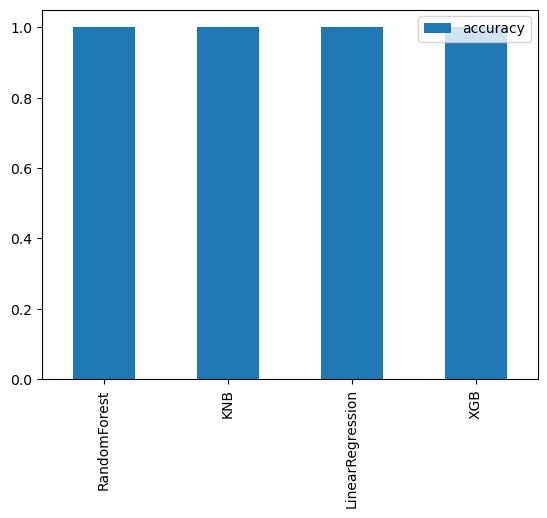

In [9]:
model_compare = pd.DataFrame(model_scores, index=["accuracy"])
model_compare.T.plot.bar()
plt.show()

## 6. Evaluation

1.  Accuracy, Precision, Recall, F1 score

In [10]:
model_preds = {}

print("\nModel Performance Metrics:")
for model_name, model in models.items():
    y_preds = model.predict(X_test)
    model_preds[model_name] = y_preds

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_preds) * 100
    precision = precision_score(y_test, y_preds, average='weighted')
    recall = recall_score(y_test, y_preds, average='weighted')
    f1 = f1_score(y_test, y_preds, average='weighted')

    # Print results in the required format
    print(f"\n{model_name} Model:")
    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")


Model Performance Metrics:

RandomForest Model:
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

KNB Model:
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

LinearRegression Model:
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1 Score: 1.00

XGB Model:
Accuracy: 100.00%
Precision: 1.00
Recall: 1.00
F1 Score: 1.00


2. Confusion Matrix


 Confusion Matrices:
Confusion Matrix Plot for RandomForest:



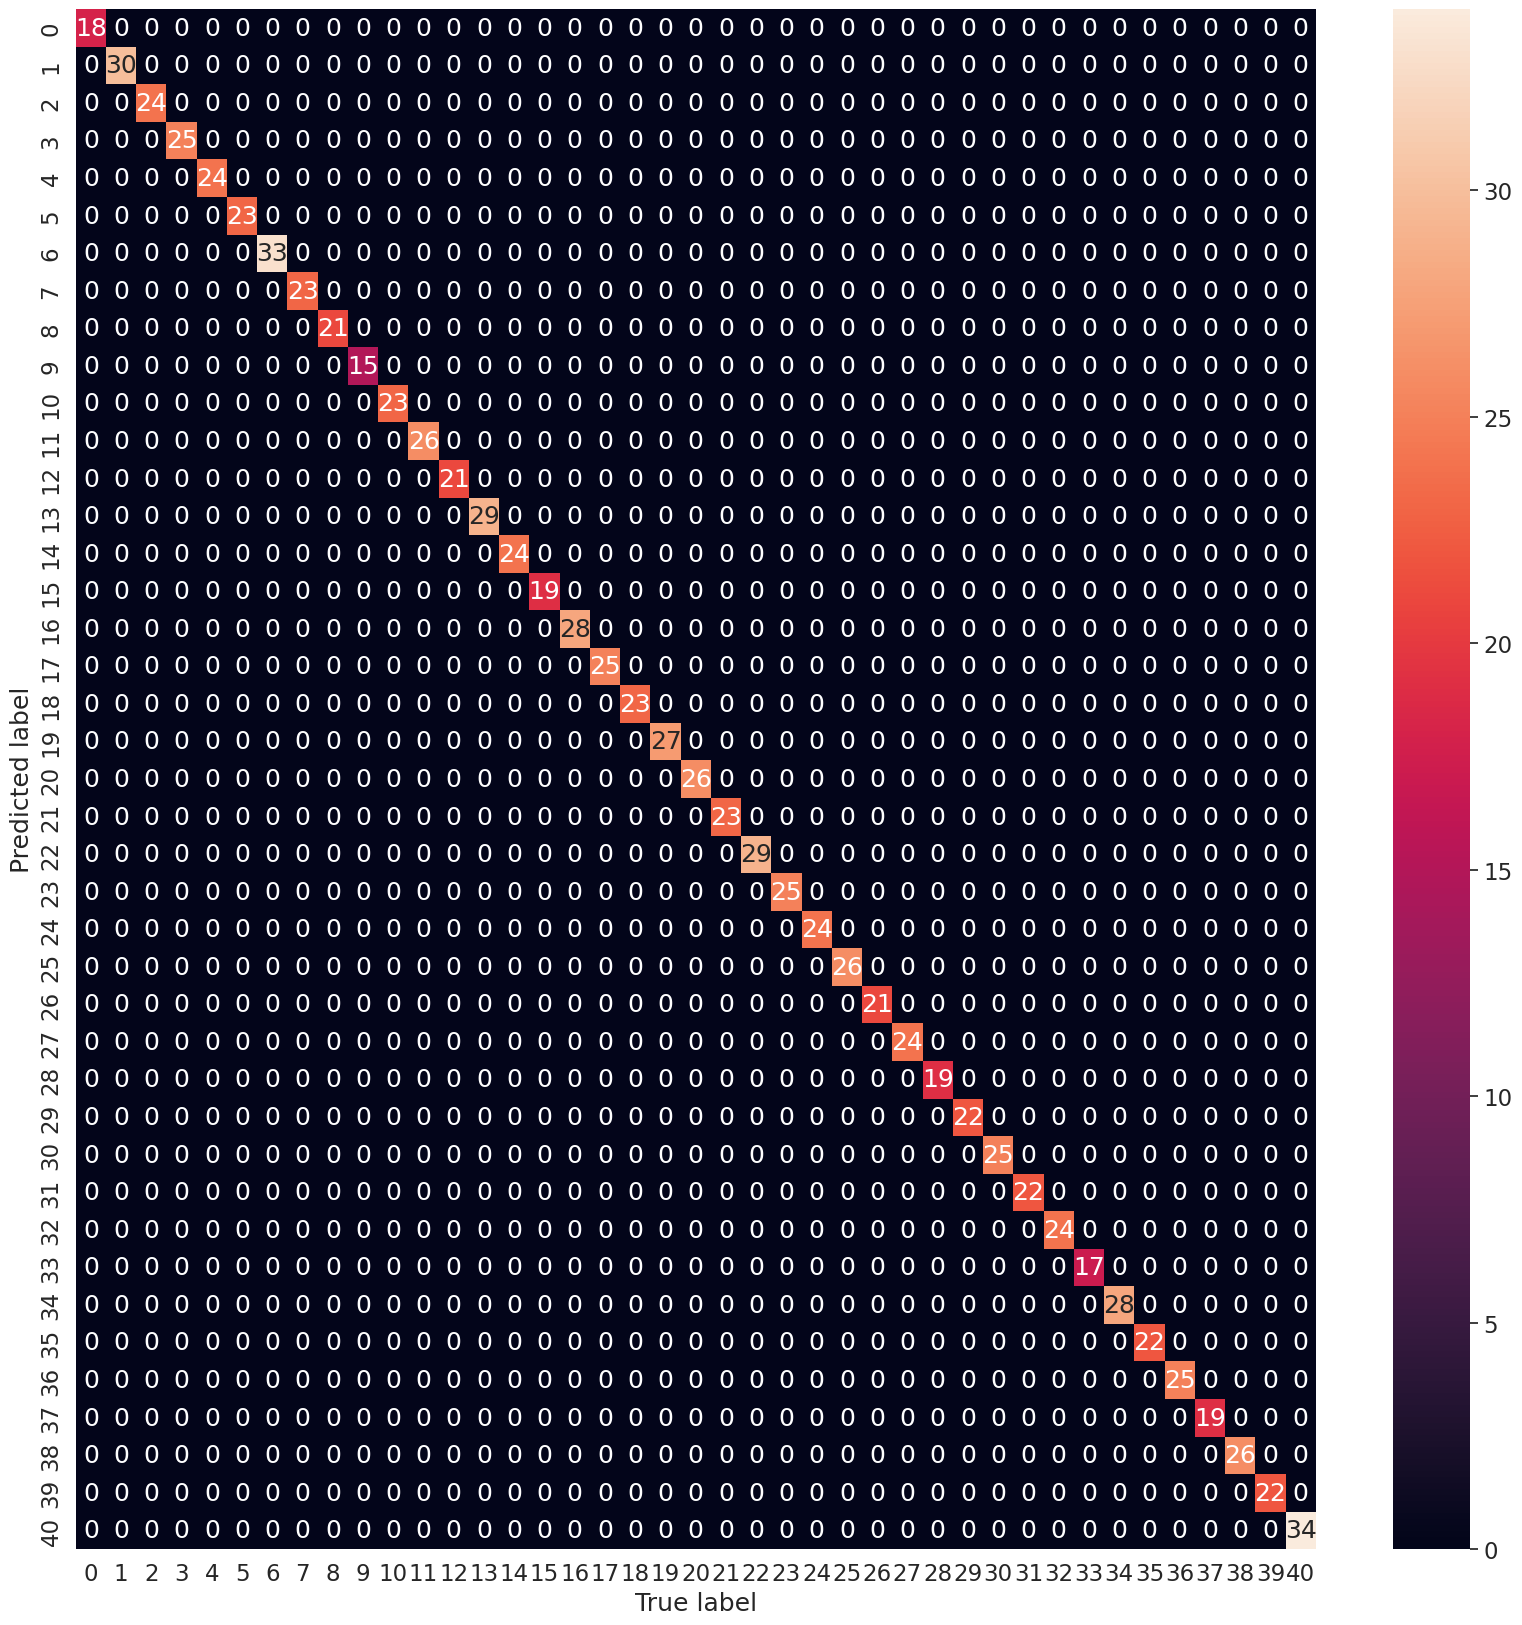

Confusion Matrix Plot for KNB:



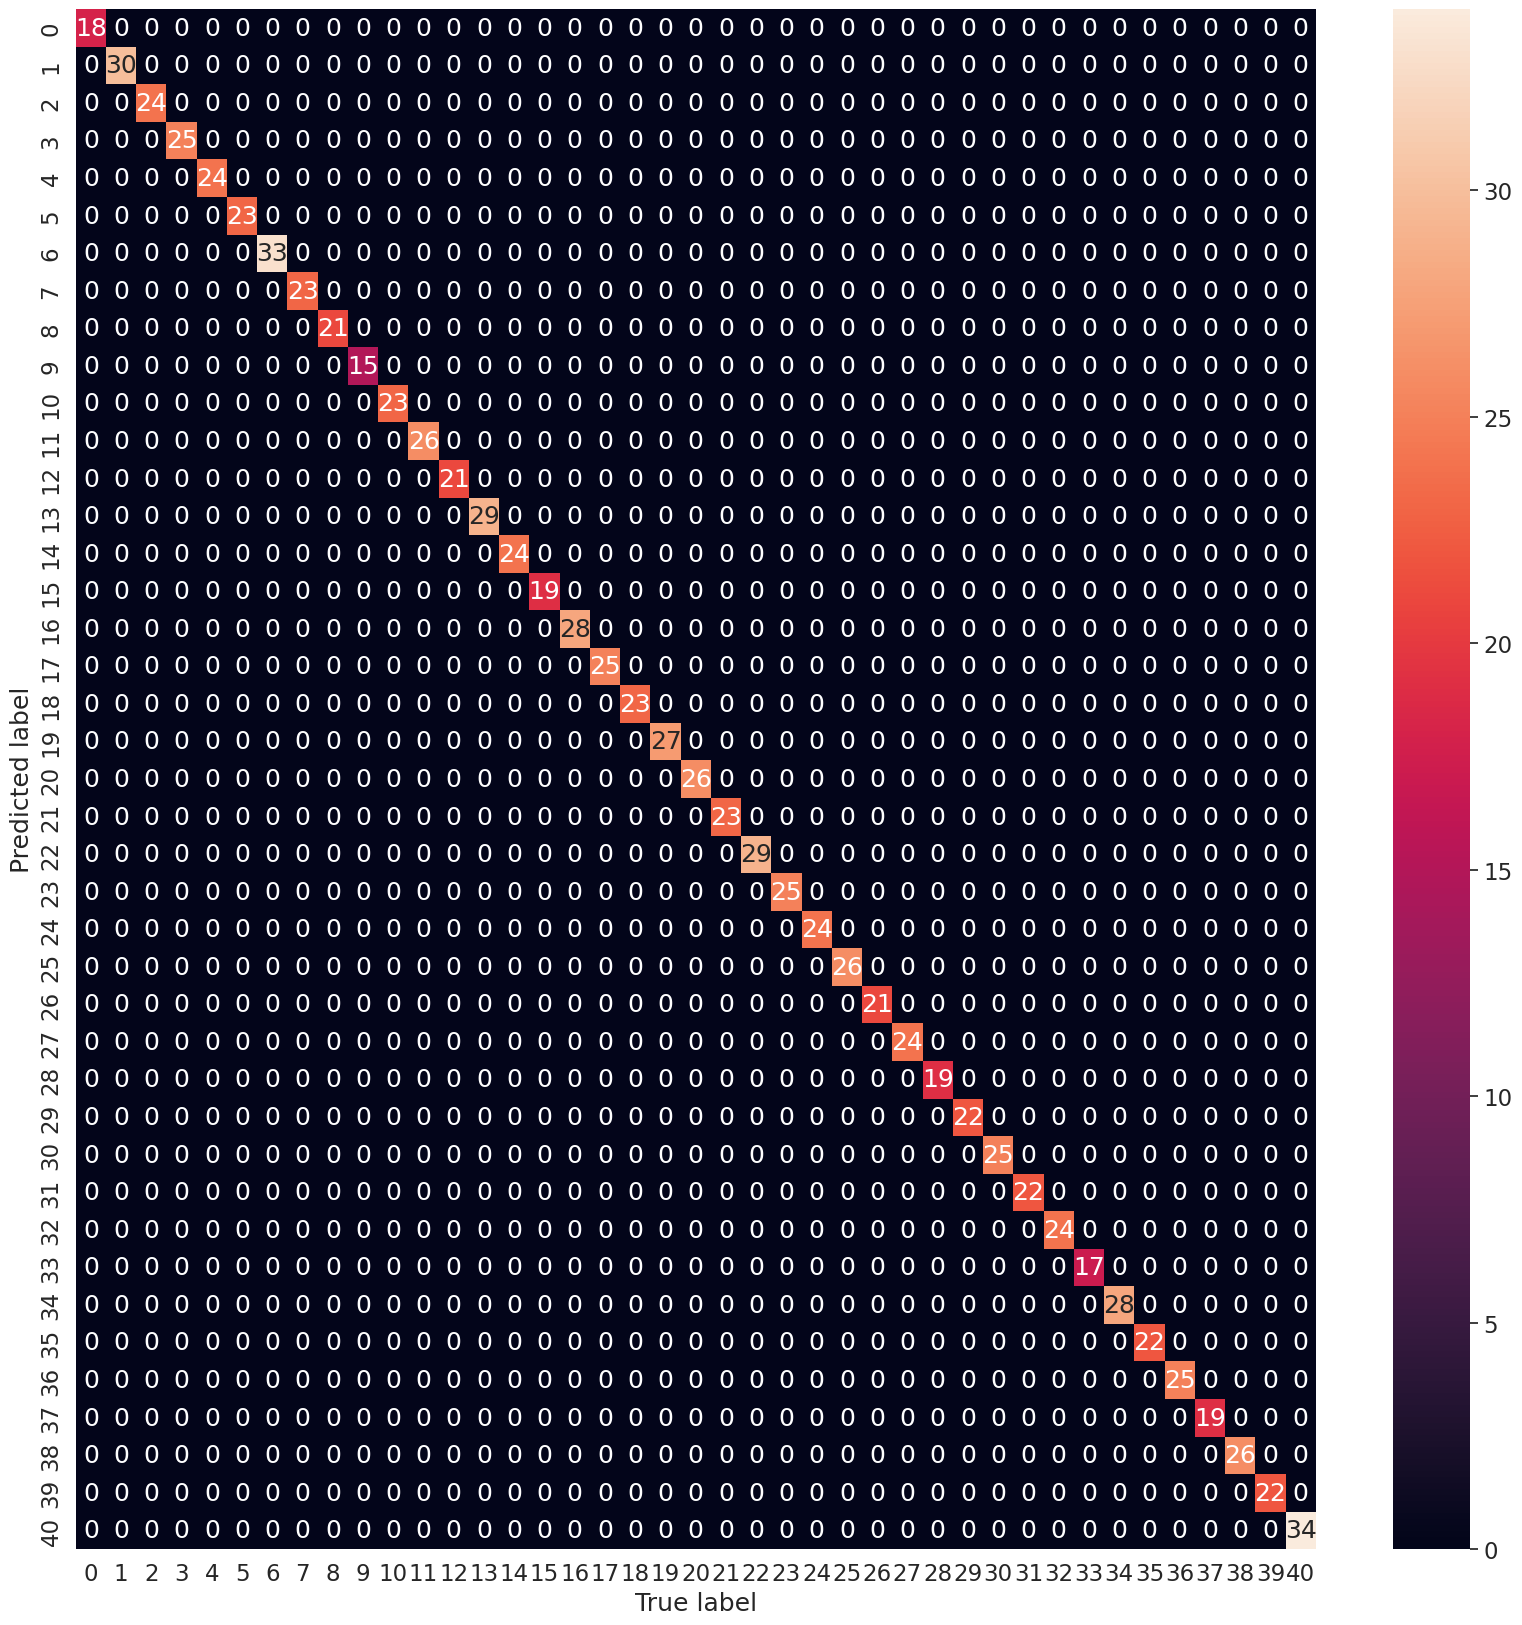

Confusion Matrix Plot for LinearRegression:



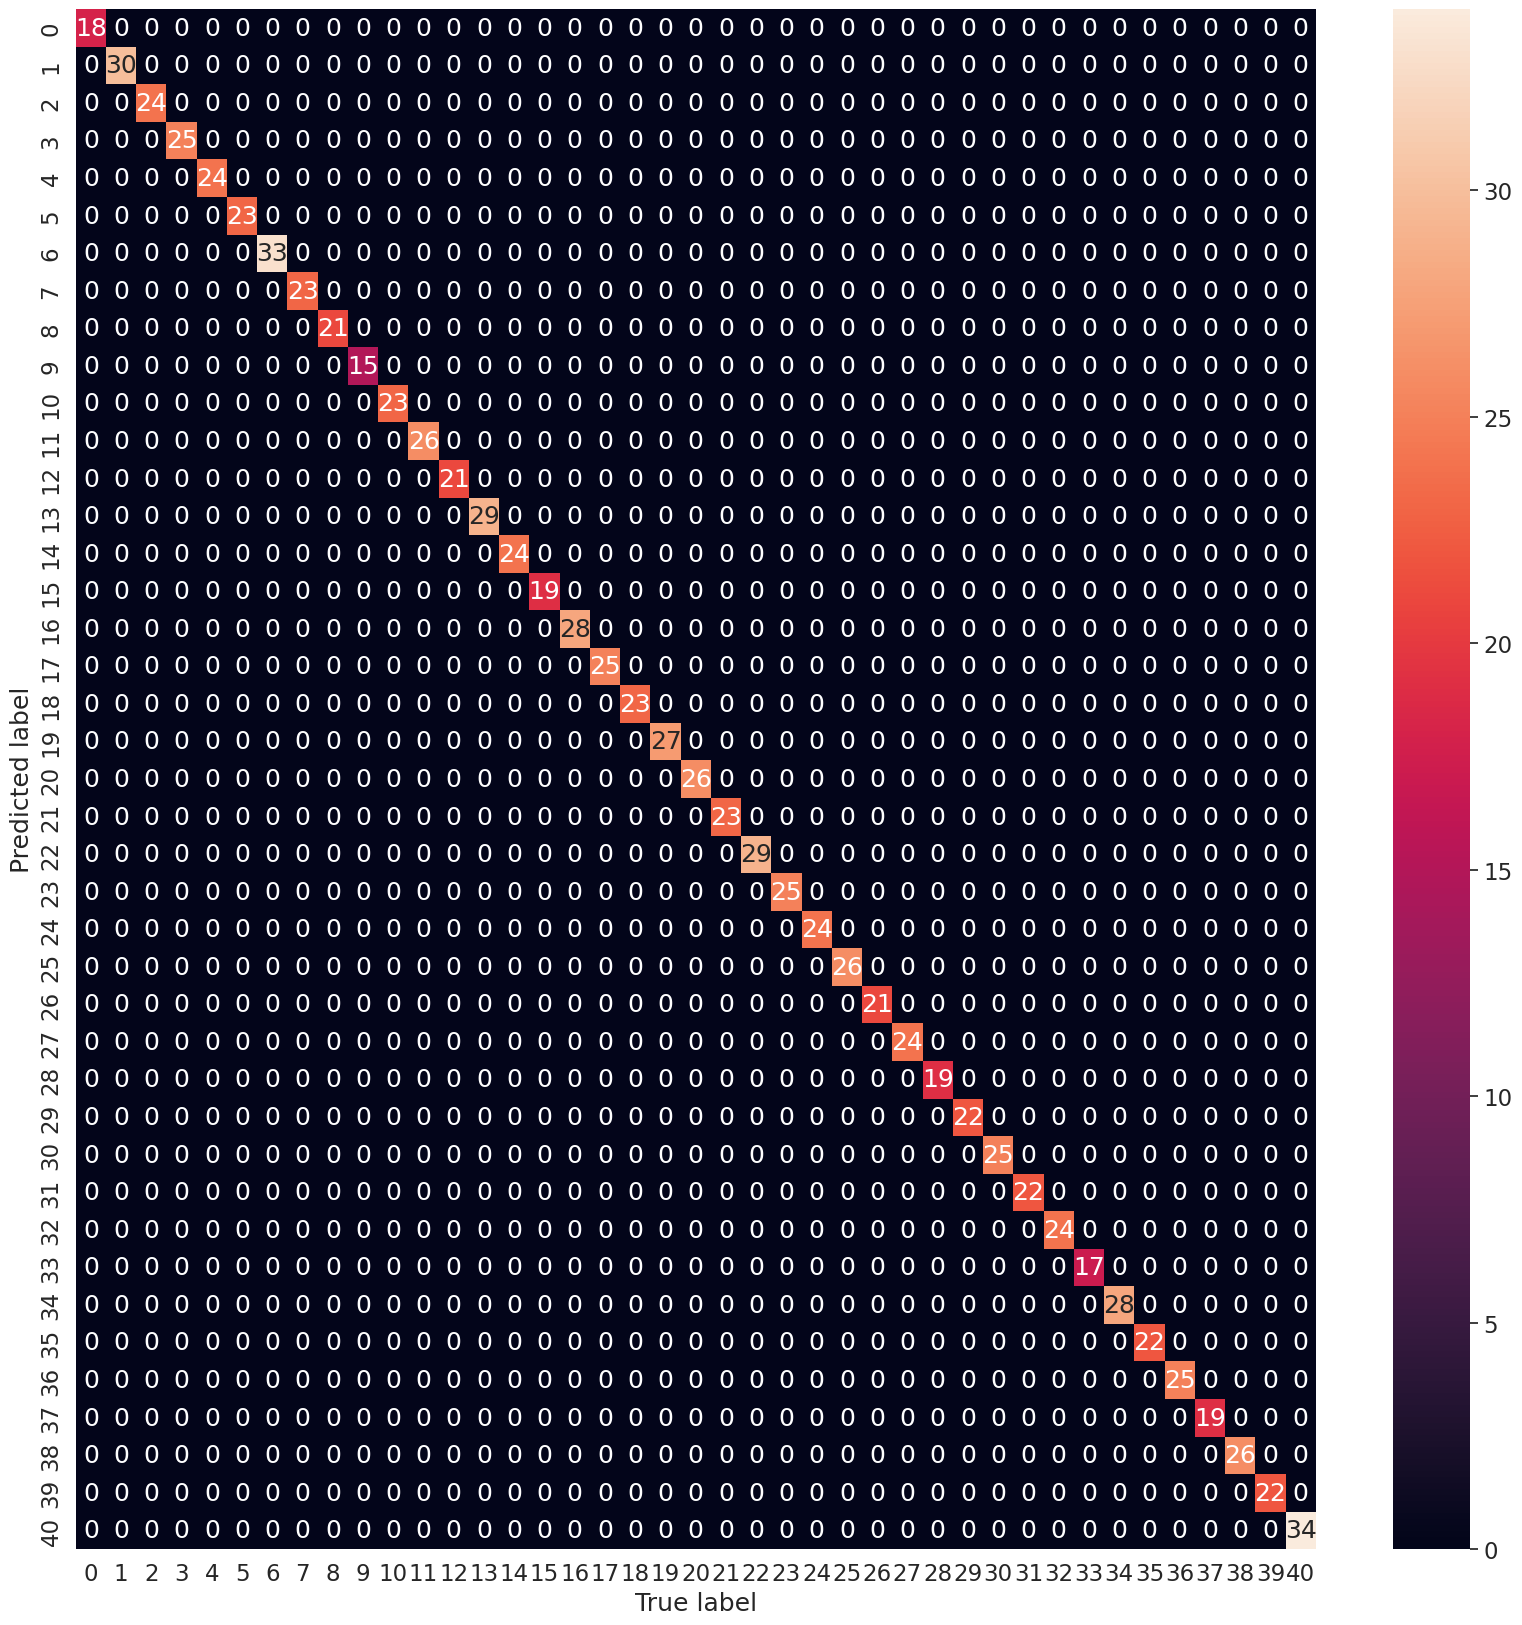

Confusion Matrix Plot for XGB:



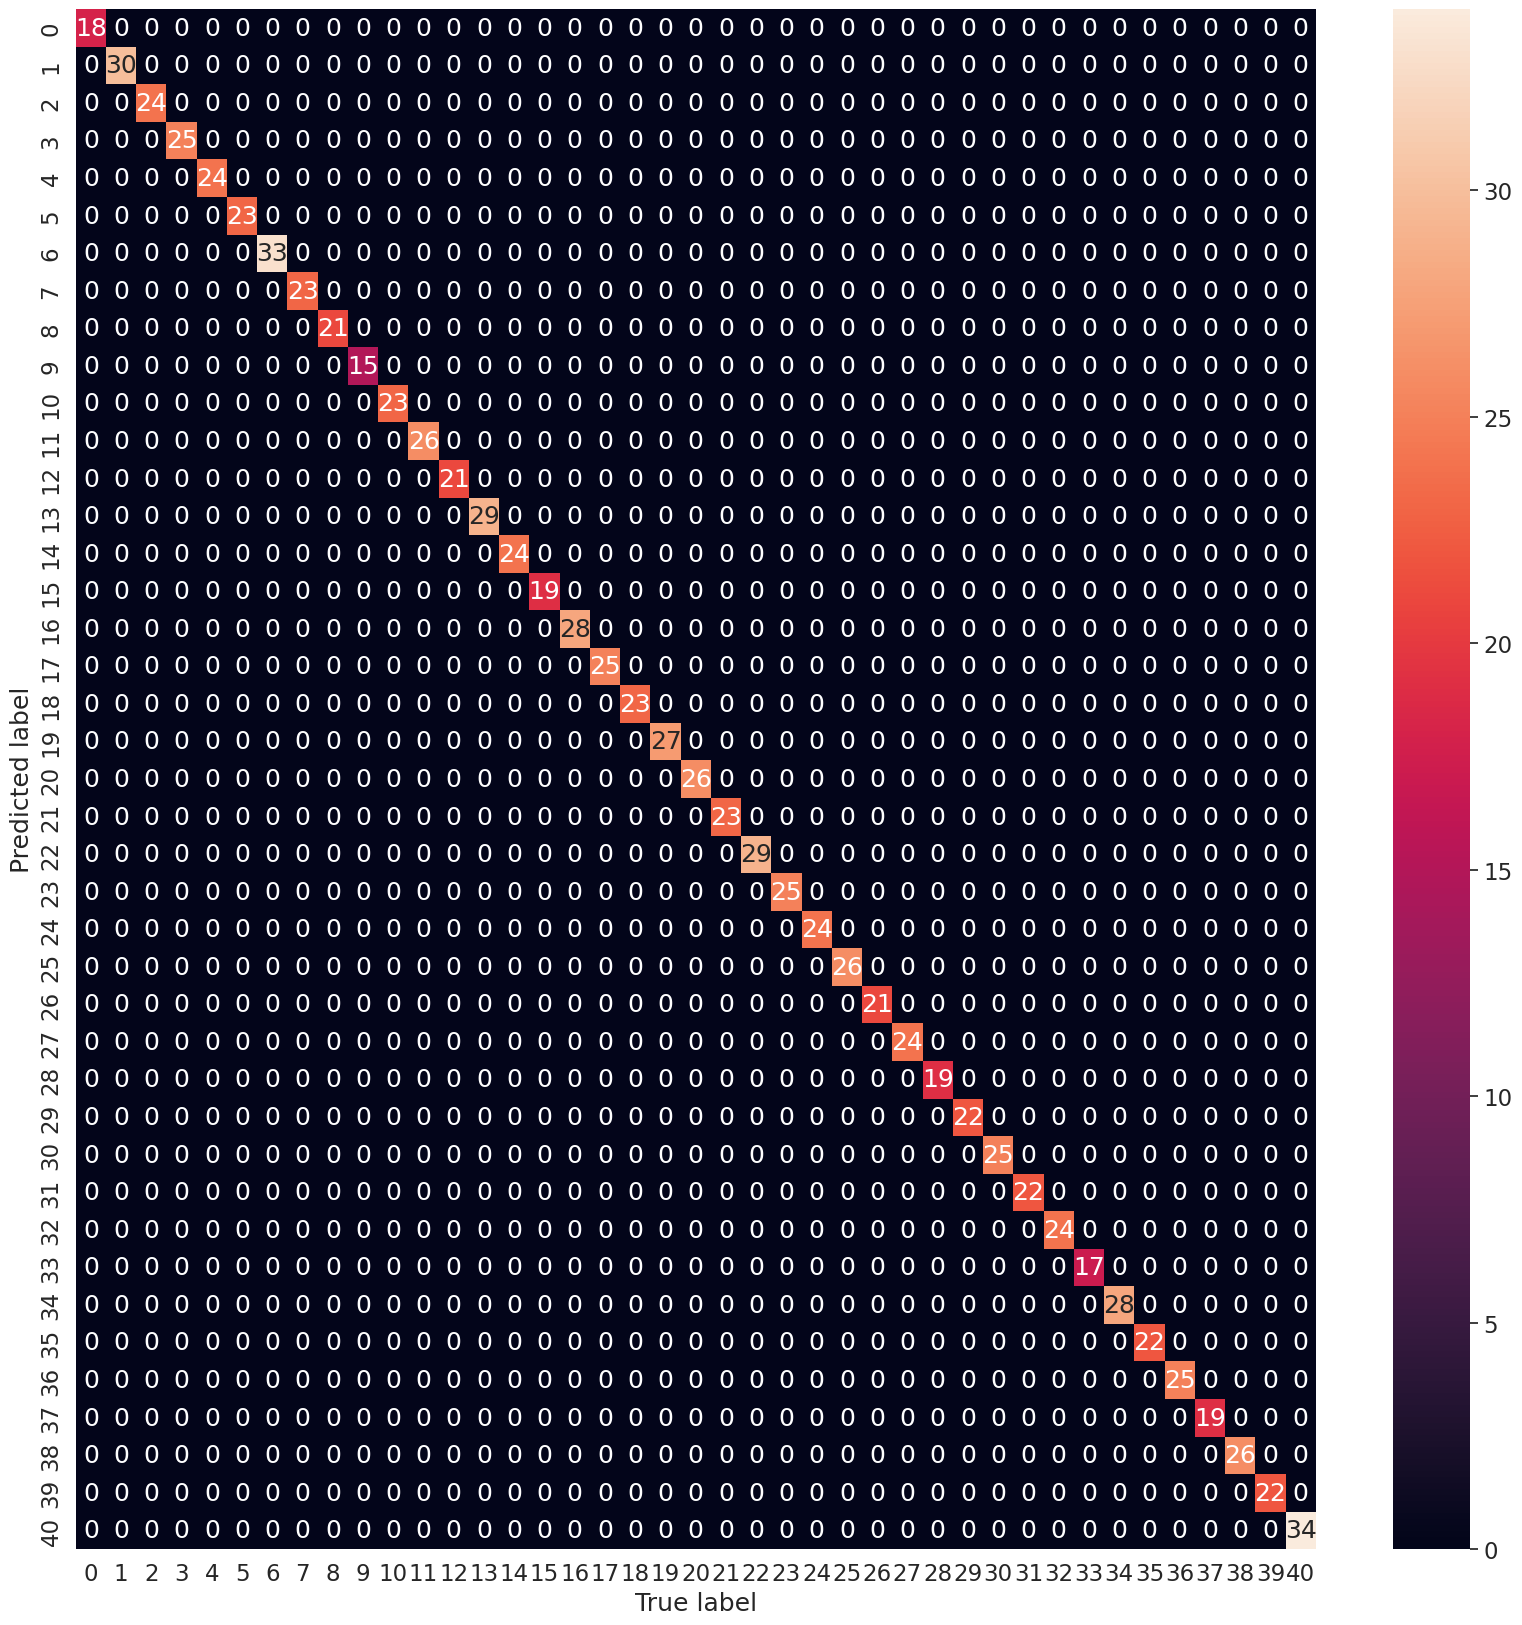

In [11]:
confusion_matrices = {}

print("\n Confusion Matrices:")
for model_name, model in models.items():
    sns.set(font_scale=1.5)
    print(f"Confusion Matrix Plot for {model_name}:\n")
    fig, ax = plt.subplots(figsize=(20, 20))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True,
                     cbar=True)
    plt.xlabel("True label")
    plt.ylabel("Predicted label")
    plt.show()


## 7. Experimentation

#### Picking a single model for Prediction

In [89]:
random_forest = models["RandomForest"]

In [90]:
print(f"Original Test Data: \n" , y_test)
print("" * 100)
print("=" * 100)
print("" * 100)
print(f"Model Prediction Data: \n" , my_model.predict(X_test))

Original Test Data: 
 [ 2  2 24  1  9 23 25  5 19 30 38 12 21 35  3  3 13 22 12  7  6 40 19  6
  4 20 34 30 26 30  9 19 17 22 39 30 28 14 34 38 20  0 23 12 28 17 25 19
 35 35 18 36 39  4 24 20 37 10 38 33 25 24 36 18  0 26 32  1  0 13 15  6
  2 22 26  9 27 27 10 30 16 27 16 14 19  1 28 17  0 11 26 29 21  3 36 17
 29 18 34 11 23  6  3  4 33 39 16 30 22  1 21 39 18 25 12 14 26 28 25  3
  7 35 32  8  5 34 17 24 35 31 11  7  7  7  9  2 19 34 13 37 33 18 35 19
 21 31 14 39 36  3 12 31 33 37 23 37 25 21  3  4  6 28  1 18 40 37 29  6
 27 24 40 21 40 17 34 27  1 40 10  8 29  1  4 40 30 37 12 19 11 38 37  2
 39 34 22  8 15  7 19 31 17 40 39 11 15  0 16  4  9  8 19 31 18 13 17 28
 29 18  9 21 11  3  3 23 32 40  8 17 26 35  5 13 37 34 35 14 31  6 12  5
 10 20  4 39 32 36 36  9 32 18 19 22 13 11 27 34 13 10 10  1 18 10 10 14
  0 26 10  8 13 25 26  5 29 37 26 16 30 27 34  1 37 24 40 35 24 33  6 36
 12 33 16 11 22 40 15 11 19 14  1 15 36  6 27 22 35 19 23 31 16 32 20 15
 33  1 25  7  6 20 13 15 40 2

Printing the names of symptoms for Experimentation and Prediction

In [92]:
print(X.columns.tolist())

['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_pain', 'weakness_in_limbs', 'fast_heart_rate', 'pain_during_bow

In [98]:
def predict_disease():
    symptoms = input("Please type your symptoms separated by comma: ").lower()
    print(f"Symptoms are: {symptoms}")
    symptoms_list = [s.strip() for s in symptoms.split(",")]
    input_vector = np.zeros(len(X.columns))
    for symptoms in symptoms_list:
        index = X.columns.get_loc(symptoms)
        input_vector[index] = 1

    prediction = random_forest.predict([input_vector])[0]
    disease = le.classes_[prediction]
    severity_score = symptoms_severity_df[symptoms_severity_df["Symptom"].isin(symptoms_list)]["weight"].sum()
    diets = diet_df[diet_df["Disease"] == disease]["Diet"].values[0]
    workouts = workout_df[workout_df["disease"] == disease]["workout"].tolist()
    precautions = precautions_df[precautions_df["Disease"] == disease][["Precaution_1", "Precaution_2", "Precaution_3", "Precaution_4"]].values[0]
    medications = medications_df[medications_df["Disease"] == disease]["Medication"].values[0]
    description = description_df[description_df["Disease"] == disease]["Description"].values[0]
    print("=" * 60)
    print("DISEASE PREDICTION AND RECOMMENDATION SYSTEM".center(60))
    print("=" * 60)
    print("=" * 60)
    print(f"Disease predicted is: {disease}")
    print("=" * 60)
    print(f"Description: {description}")
    print("-" * 60)
    print(f"Severity Score: {severity_score}")
    print("-" * 60)
    print(f"Precautions: {precautions}")
    print("-" * 60)
    print(f"Medications: {medications}")
    print("-" * 60)
    print(f"Diets: {diets}")
    print("-" * 60)
    print(f"Workouts: {workouts}")
    print("=" * 60)


In [99]:
predict_disease()

Symptoms are: chills, vomiting, high_fever, sweating, headache, nausea, diarrhoea, muscle_pain
        DISEASE PREDICTION AND RECOMMENDATION SYSTEM        
Disease predicted is: Malaria
Description: Malaria is a mosquito-borne infectious disease affecting humans and other animals.
------------------------------------------------------------
Severity Score: 34
------------------------------------------------------------
Precautions: ['Consult nearest hospital' 'avoid oily food' 'avoid non veg food'
 'keep mosquitos out']
------------------------------------------------------------
Medications: ['Antimalarial drugs', 'Antipyretics', 'Antiemetic drugs', 'IV fluids', 'Blood transfusions']
------------------------------------------------------------
Diets: ['Malaria Diet', 'Hydration', 'High-Calorie Diet', 'Soft and bland foods', 'Oral rehydration solutions']
------------------------------------------------------------
Workouts: ['Stay hydrated', 'Consume nutrient-rich foods', 'Include prot

### Saving the Model

In [ ]:
from joblib import dump

dump(random_forest, filename="ml/models/Random-Forest-Model.joblib")